# Strict vs Relaxed vs Oracle CatBoost Comparison with pAUC@88

이 notebook은 `Strict (최종 메인 세트)`, `Relaxed (보조용)`, `Oracle (참고용)`를 같은 split, 같은 CatBoost 설정, 같은 `pAUC@TPR>=0.88` 기준으로 직접 비교하기 위한 notebook이다.

이번 비교의 목적은 다음과 같다.
1. 메인 실험 세트인 `Strict`의 고민감도 구간 성능을 기준선으로 둔다.
2. `Relaxed`가 출처·맥락 정보를 더했을 때 얼마나 성능이 오르는지 본다.
3. `Oracle`이 진단 사후 정보를 포함했을 때 leakage 상한선이 어디까지 올라가는지 본다.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, roc_auc_score, average_precision_score, log_loss, brier_score_loss, precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix
from catboost import CatBoostClassifier, Pool

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

base_dir = Path('/home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024')
input_dir = base_dir / 'model_inputs'
split_path = base_dir / 'splits' / 'train_metadata_with_internal_split.csv'
manifest_path = input_dir / 'strict_full_vs_final_strict_feature_manifest.json'
out_dir = base_dir / 'modeling' / 'final_strict_vs_relaxed_vs_oracle_catboost'
out_dir.mkdir(parents=True, exist_ok=True)

random_state = 42
PRIMARY_MIN_TPR = 0.88
SECONDARY_MIN_TPR = 0.80
PRIMARY_MAX_FPR = 1 - PRIMARY_MIN_TPR

DISPLAY_NAME = {
    'final_strict': 'Strict',
    'relaxed': 'Relaxed',
    'oracle': 'Oracle',
}
DISPLAY_COLOR = {
    'final_strict': '#0072B2',
    'relaxed': '#72B7B2',
    'oracle': '#E45756',
}

catboost_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'depth': 6,
    'learning_rate': 0.05,
    'iterations': 400,
    'random_seed': random_state,
    'verbose': False,
    'auto_class_weights': 'Balanced',
}

print('out_dir =', out_dir)
print('primary metric = pAUC@TPR>=', PRIMARY_MIN_TPR)
print('secondary metric = pAUC@TPR>=', SECONDARY_MIN_TPR)


out_dir = /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/final_strict_vs_relaxed_vs_oracle_catboost
primary metric = pAUC@TPR>= 0.88
secondary metric = pAUC@TPR>= 0.8


## 1. 입력 테이블 구성

코드 셀에서는 이미 저장된 `Strict` 입력 테이블을 기준으로 `Relaxed`, `Oracle` 입력 테이블을 같은 split 위에서 재구성한다.

이번 구현에서는 최종 방향과 맞추기 위해 다음 가정을 사용한다.
1. `Strict`는 이미 채택된 최종 메인 세트다.
2. `Relaxed`는 `Strict + attribution + copyright_license`로 둔다.
3. `Oracle`은 `Relaxed`에 진단 사후 정보와 병리 보조 정보를 추가한다.


In [2]:
split_df = pd.read_csv(split_path, low_memory=False)
manifest = json.loads(manifest_path.read_text())
final_strict_feature_columns = manifest['final_strict_feature_columns']
common_meta_columns = manifest['common_meta_columns']

strict_paths = {
    'train': input_dir / 'isic2024_final_strict_train_input.parquet',
    'validation': input_dir / 'isic2024_final_strict_validation_input.parquet',
    'internal_test': input_dir / 'isic2024_final_strict_internal_test_input.parquet',
}
strict_data = {split: pd.read_parquet(path) for split, path in strict_paths.items()}

relaxed_extra_cols = ['attribution', 'copyright_license']
oracle_categorical_extra_cols = ['lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5']
oracle_numeric_extra_cols = ['mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence']

train_raw = split_df.loc[split_df['split'] == 'train'].copy()
oracle_numeric_median_map = {}
for c in oracle_numeric_extra_cols:
    med = pd.to_numeric(train_raw[c], errors='coerce').median()
    oracle_numeric_median_map[c] = float(0.0 if pd.isna(med) else med)

oracle_numeric_missing_indicator_cols = [
    c for c in oracle_numeric_extra_cols
    if pd.to_numeric(train_raw[c], errors='coerce').isna().mean() > 0
]

lookup_cols = ['isic_id'] + relaxed_extra_cols + oracle_categorical_extra_cols + oracle_numeric_extra_cols
raw_lookup = split_df[lookup_cols].copy()


def build_regime_frame(base_df, regime_name):
    merged = base_df.merge(raw_lookup, on='isic_id', how='left')
    if regime_name in ['relaxed', 'oracle']:
        for c in relaxed_extra_cols:
            merged[c] = merged[c].fillna('Missing').astype(str)
    if regime_name == 'oracle':
        for c in oracle_categorical_extra_cols:
            merged[c] = merged[c].fillna('Missing').astype(str)
        for c in oracle_numeric_extra_cols:
            merged[c] = pd.to_numeric(merged[c], errors='coerce').fillna(oracle_numeric_median_map[c])
        for c in oracle_numeric_missing_indicator_cols:
            merged[f'{c}__missing'] = raw_lookup.set_index('isic_id').loc[merged['isic_id'], c].isna().astype(int).to_numpy()
    keep_cols = common_meta_columns + final_strict_feature_columns
    if regime_name in ['relaxed', 'oracle']:
        keep_cols += relaxed_extra_cols
    if regime_name == 'oracle':
        keep_cols += oracle_categorical_extra_cols + oracle_numeric_extra_cols + [f'{c}__missing' for c in oracle_numeric_missing_indicator_cols]
    return merged[keep_cols].copy()

regime_data = {'final_strict': strict_data}
for regime_name in ['relaxed', 'oracle']:
    regime_data[regime_name] = {split: build_regime_frame(strict_data[split], regime_name) for split in strict_data}

save_name_map = {
    'relaxed': 'relaxed',
    'oracle': 'oracle',
}
for regime_name in ['relaxed', 'oracle']:
    for split, df in regime_data[regime_name].items():
        df.to_parquet(input_dir / f'isic2024_{save_name_map[regime_name]}_{split}_input.parquet', index=False)

input_summary_rows = []
for regime_name, split_map in regime_data.items():
    for split, df in split_map.items():
        feature_cols = [c for c in df.columns if c not in common_meta_columns]
        input_summary_rows.append({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME[regime_name],
            'split': split,
            'n_rows': int(df.shape[0]),
            'n_positive_rows': int(df['target'].sum()),
            'n_feature_columns': len(feature_cols),
            'n_categorical_features': int(df[feature_cols].select_dtypes(include='object').shape[1]),
            'n_numeric_features': int(df[feature_cols].select_dtypes(exclude='object').shape[1]),
        })
input_summary_df = pd.DataFrame(input_summary_rows)
display(input_summary_df)
input_summary_df.to_csv(out_dir / 'final_strict_vs_relaxed_vs_oracle_input_summary.csv', index=False)


/home/junkim2603a/miniconda3/envs/paper_ajou_dev/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,regime,regime_display,split,n_rows,n_positive_rows,n_feature_columns,n_categorical_features,n_numeric_features
0,final_strict,Strict,train,280335,270,51,5,46
1,final_strict,Strict,validation,65684,57,51,5,46
2,final_strict,Strict,internal_test,55040,66,51,5,46
3,relaxed,Relaxed,train,280335,270,53,7,46
4,relaxed,Relaxed,validation,65684,57,53,7,46
5,relaxed,Relaxed,internal_test,55040,66,53,7,46
6,oracle,Oracle,train,280335,270,65,14,51
7,oracle,Oracle,validation,65684,57,65,14,51
8,oracle,Oracle,internal_test,55040,66,65,14,51


## 2. pAUC 함수와 임상 threshold 기준

코드 셀에는 이번 비교에서 사용하는 `pAUC@TPR>=0.88` 계산 함수가 들어 있다.

핵심 정의는 다음과 같다.
- `pAUC = \int_0^{max_fpr} TPR(FPR) dFPR`
- `max_fpr = 1 - min_tpr`
- 이번 notebook에서는 `min_tpr = 0.88`, 따라서 `max_fpr = 0.12`

또한 threshold는 `validation`에서 `TPR>=0.88`을 만족하면서 specificity가 가장 높은 값으로 고른다.


In [3]:
def p_auc_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    # pAUC@TPR>=min_tpr = \int_0^{max_fpr} TPR(FPR) dFPR
    # where max_fpr = 1 - min_tpr.
    # For min_tpr=0.88, we only integrate the ROC curve up to FPR=0.12.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    max_fpr = 1.0 - float(min_tpr)
    if not 0 < max_fpr <= 1:
        raise ValueError(f'Expected min_tpr in (0, 1], got {min_tpr}')
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    if max_fpr >= fpr[-1]:
        return auc(fpr, tpr)
    stop_idx = np.searchsorted(fpr, max_fpr, side='right')
    fpr_clip = np.concatenate([fpr[:stop_idx], [max_fpr]])
    tpr_clip = np.concatenate([tpr[:stop_idx], [np.interp(max_fpr, fpr, tpr)]])
    return auc(fpr_clip, tpr_clip)


def choose_threshold_by_min_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    eligible = np.where(tpr >= min_tpr)[0]
    if len(eligible) == 0:
        best_idx = int(np.argmax(tpr))
    else:
        best_idx = eligible[np.argmin(fpr[eligible])]
    selected_threshold = thresholds[best_idx]
    selected_tpr = tpr[best_idx]
    selected_specificity = 1 - fpr[best_idx]
    return float(selected_threshold), float(selected_tpr), float(selected_specificity)


def compute_metrics(y_true, y_prob, y_pred, split, regime_name, best_iteration, selected_threshold, val_selected_tpr, val_selected_specificity, n_feature_columns):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'regime': regime_name,
        'regime_display': DISPLAY_NAME[regime_name],
        'split': split,
        'pauc_tpr88': float(p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)),
        'pauc_tpr80': float(p_auc_tpr(y_true, y_prob, SECONDARY_MIN_TPR)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'average_precision': float(average_precision_score(y_true, y_prob)),
        'log_loss': float(log_loss(y_true, y_prob, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'specificity': float(specificity),
        'predicted_positive_rate': float(np.mean(y_pred)),
        'threshold_from_validation_tpr88': float(selected_threshold),
        'validation_selected_tpr': float(val_selected_tpr),
        'validation_selected_specificity': float(val_selected_specificity),
        'best_iteration': int(best_iteration),
        'n_rows': int(len(y_true)),
        'n_positive_rows': int(np.sum(y_true)),
        'n_feature_columns': int(n_feature_columns),
    }


## 3. CatBoost 학습과 성능 비교표

코드 셀에서는 세 regime를 모두 같은 CatBoost 설정으로 학습한다. 이후 `validation`에서 고른 clinical threshold를 그대로 `internal_test`에 적용하고, `pAUC@TPR>=0.88`를 가장 먼저 비교한다.


In [4]:
def prepare_xy(df):
    X = df.drop(columns=common_meta_columns).copy()
    y = df['target'].astype(int).to_numpy()
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    for c in cat_cols:
        X[c] = X[c].fillna('Missing').astype(str)
    for c in X.columns.difference(cat_cols):
        X[c] = pd.to_numeric(X[c], errors='coerce')
    return X, y, cat_cols


def fit_and_score(regime_name, split_map):
    X_train, y_train, cat_cols = prepare_xy(split_map['train'])
    X_val, y_val, _ = prepare_xy(split_map['validation'])
    X_test, y_test, _ = prepare_xy(split_map['internal_test'])

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)

    model = CatBoostClassifier(**catboost_params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_prob = model.predict_proba(val_pool)[:, 1]
    test_prob = model.predict_proba(test_pool)[:, 1]

    selected_threshold, val_selected_tpr, val_selected_specificity = choose_threshold_by_min_tpr(y_val, val_prob, PRIMARY_MIN_TPR)
    val_pred = (val_prob >= selected_threshold).astype(int)
    test_pred = (test_prob >= selected_threshold).astype(int)

    metrics = [
        compute_metrics(y_val, val_prob, val_pred, 'validation', regime_name, model.get_best_iteration(), selected_threshold, val_selected_tpr, val_selected_specificity, X_train.shape[1]),
        compute_metrics(y_test, test_prob, test_pred, 'internal_test', regime_name, model.get_best_iteration(), selected_threshold, val_selected_tpr, val_selected_specificity, X_train.shape[1]),
    ]

    pred_df = pd.concat([
        pd.DataFrame({'split': 'validation', 'isic_id': split_map['validation']['isic_id'], 'target': y_val, 'y_prob': val_prob, 'y_pred': val_pred}),
        pd.DataFrame({'split': 'internal_test', 'isic_id': split_map['internal_test']['isic_id'], 'target': y_test, 'y_prob': test_prob, 'y_pred': test_pred}),
    ], ignore_index=True)
    pred_df['regime'] = regime_name
    pred_df['regime_display'] = DISPLAY_NAME[regime_name]

    fi_df = pd.DataFrame({
        'feature_name': X_train.columns,
        'importance': model.get_feature_importance(train_pool),
        'regime': regime_name,
        'regime_display': DISPLAY_NAME[regime_name],
    }).sort_values('importance', ascending=False)
    return pd.DataFrame(metrics), pred_df, fi_df

metrics_parts, pred_parts, fi_parts = [], [], []
for regime_name in ['final_strict', 'relaxed', 'oracle']:
    m, p, f = fit_and_score(regime_name, regime_data[regime_name])
    metrics_parts.append(m)
    pred_parts.append(p)
    fi_parts.append(f)

metrics_df = pd.concat(metrics_parts, ignore_index=True)
pred_df = pd.concat(pred_parts, ignore_index=True)
fi_df = pd.concat(fi_parts, ignore_index=True)

metrics_df.to_csv(out_dir / 'final_strict_vs_relaxed_vs_oracle_catboost_metrics.csv', index=False)
pred_df.to_parquet(out_dir / 'final_strict_vs_relaxed_vs_oracle_catboost_predictions.parquet', index=False)
fi_df.to_csv(out_dir / 'final_strict_vs_relaxed_vs_oracle_catboost_feature_importance.csv', index=False)

comparison_table_df = metrics_df[['regime_display', 'split', 'pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision', 'recall', 'specificity', 'n_feature_columns']].copy()
comparison_table_df = comparison_table_df.sort_values(['split', 'pauc_tpr88'], ascending=[True, False])
comparison_table_df.to_csv(out_dir / 'final_strict_vs_relaxed_vs_oracle_catboost_pauc_summary.csv', index=False)
display(comparison_table_df)


,regime_display,split,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,recall,specificity,n_feature_columns
5,Oracle,internal_test,0.120000,0.200000,1.000000,1.000000,0.984848,1.000000,65
1,Strict,internal_test,0.086122,0.161565,0.952861,0.078308,0.939394,0.829792,51
3,Relaxed,internal_test,0.083093,0.153955,0.937065,0.068878,0.878788,0.853785,53
4,Oracle,validation,0.120000,0.200000,1.000000,1.000000,1.000000,1.000000,65
0,Strict,validation,0.085173,0.155836,0.943698,0.069540,0.894737,0.827830,51
2,Relaxed,validation,0.084710,0.155867,0.926387,0.084415,0.894737,0.855959,53


## 4. pAUC@88 중심 시각화

코드 셀에서는 split별로 `pAUC@TPR>=0.88`와 `specificity`를 나란히 보여준다. 발표에서는 이 표와 그래프를 함께 쓰면 읽기 쉽다.


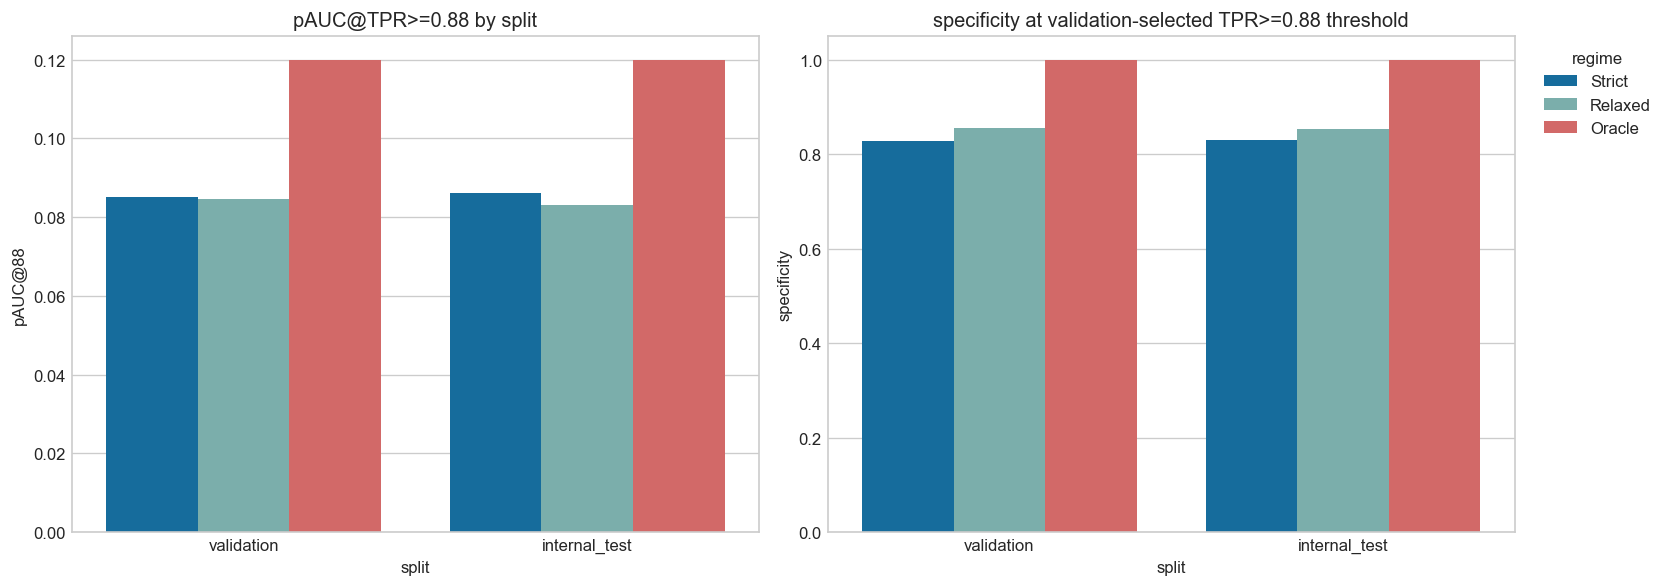

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = metrics_df.copy()

sns.barplot(data=plot_df, x='split', y='pauc_tpr88', hue='regime_display', palette=[DISPLAY_COLOR['final_strict'], DISPLAY_COLOR['relaxed'], DISPLAY_COLOR['oracle']], ax=axes[0])
axes[0].set_title('pAUC@TPR>=0.88 by split')
axes[0].set_ylabel('pAUC@88')

sns.barplot(data=plot_df, x='split', y='specificity', hue='regime_display', palette=[DISPLAY_COLOR['final_strict'], DISPLAY_COLOR['relaxed'], DISPLAY_COLOR['oracle']], ax=axes[1])
axes[1].set_title('specificity at validation-selected TPR>=0.88 threshold')
axes[1].set_ylabel('specificity')

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, title='regime', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].legend_.remove()
plt.tight_layout()
plt.show()


## 5. 해석 메모

1. `Strict`는 최종 메인 세트다.
2. `Relaxed`는 출처·맥락 정보가 추가되었을 때 성능이 얼마나 오르는지 보는 보조 비교다.
3. `Oracle`은 실제 배포용이 아니라 leakage 상한선을 보여주는 참고용 비교다.
4. 따라서 실험 해석은 항상 `Strict`를 기준으로 하고, `Relaxed`, `Oracle`은 그 위나 아래에서 상대 비교로 읽는다.
